In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing 

In [2]:
import requests
import sys
import os
import pandas as pd
import numpy as np
from pathlib import Path
import json
from typing import List, Dict, Tuple
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

palette_trend = {'Inconsistent': 'gray', 'Increase in aging': '#E52B50', 'Decrease in aging': '#B0BF1A'}
def create_nodes_edges(net) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Create nodes and edges from the input network DataFrame."""

    edges = net
    gene_names = np.concatenate([net['source'].unique(), net['target'].unique()])
    nodes = pd.DataFrame({'node': gene_names})

    # Compute out-degree and in-degree
    out_deg = net.groupby("source").size().reset_index(name="out_degree").rename(columns={"source": "node"})
    in_deg = net.groupby("target").size().reset_index(name="in_degree").rename(columns={"target": "node"})

    # Merge degrees
    centrality = pd.merge(out_deg, in_deg, on="node", how="outer").fillna(0)
    centrality["centrality"] = centrality["in_degree"] + centrality["out_degree"]

    # Trend from both source and target
    meta_source = net[['source', 'trend_source']].drop_duplicates().rename(columns={'source': 'node', 'trend_source': 'trend'})
    meta_target = net[['target', 'trend_target']].drop_duplicates().rename(columns={'target': 'node', 'trend_target': 'trend'})

    # Combine trends: source has priority
    meta_combined = pd.concat([meta_target, meta_source]).drop_duplicates(subset='node', keep='last')

    # Merge info into nodes
    nodes = nodes.merge(centrality[['node', 'centrality']], on='node', how='left')
    nodes = nodes.merge(meta_combined, on='node', how='left')

    # Fill missing values
    nodes['centrality'] = nodes['centrality'].fillna(1)
    nodes['trend'] = nodes['trend'].fillna('Unknown')

    # Assign color using trend
    nodes['color'] = nodes['trend'].map(palette_trend).fillna('#FFFFFF')  # fallback to white

    return nodes, edges

class PlotCytoscape:
    palette_regulation = {'Positive': '#009E73', 'Negative': 'lightcoral'}
    

    def __init__(self, nodes, edges, node_size_attribute=None, edge_color_attribute=None, edge_size_attribute=None):
        assert (len(nodes) > 0)
        assert (len(edges) > 0)
        # - scale node size
        if node_size_attribute is not None:
            scale, min_value = 20, 20
            nodes["size"] = self.normalize(nodes[node_size_attribute], scale=scale, min_value=min_value)
        # - scale edge width
        if edge_size_attribute is not None:
            scale, min_value = 3, 1
            # edges["width"] = self.normalize(edges[edge_size_attribute], scale=scale,
            #                                              min_value=min_value)
            edges["width"] = 1
        # - assign color to edges
        # if edge_color_attribute is not None:
        #     edges['edge_color'] = self.assign_edge_colors(edges[edge_color_attribute])
        edges['edge_color'] = 'black'
        # - assign arrow shape and size
        edges["arrow_shape"] = self.assign_arrow_shapes(edges["weight"])
        edges["arrow_size"] = self.assign_arrow_sizes(edges["weight"])


        self.base = 'http://localhost:' + str(1234) + '/v1/'
        self.ID = None
        self.nodes = self.extract_dict(nodes.rename(columns={'node': 'id'}))
        self.edges = self.extract_dict(edges)

    # @classmethod
    # def assign_edge_colors(cls, values):
    #     colors = []
    #     for val in values:
    #         if val >= 0:
    #             colors.append(cls.palette_regulation['Positive'])
    #         else:
    #             colors.append(cls.palette_regulation['Negative'])
    #     return colors
    @classmethod
    def assign_arrow_shapes(cls, values):
        arrows = []
        for val in values:
            if val >= 0:
                arrows.append('DELTA_SHORT_1')       # or 'DELTA'
            else:
                arrows.append('T')           # 'T' is the blocking head in Cytoscape
        return arrows
    def assign_arrow_sizes(self, values):
        return [4 if v < 0 else 8 for v in values]
    @staticmethod
    def normalize(values, scale=1, min_value=0):
        min_val = min(values)
        max_val = max(values)
        if min_val == max_val:
            return values
        normalized_values = [min_value+ (val - min_val) / (max_val - min_val)*scale for val in values]
        return normalized_values
    @staticmethod
    def extract_dict(df) -> List[Dict]:
        """
        Puts the df into a list of dict where it presents each row of the df
        """
        nodes_dict = df.to_dict('records')
        list_of_data = []
        for node in nodes_dict:
            data = {'data': {}}
            for col in df.columns:
                data['data'][col] = node[col]
            list_of_data.append(data)
        return list_of_data
    def _delete_network(self, name):
        """
            If the name exist, delete the network before creating it
        """
        response = requests.get(self.base + 'networks.names')
        networks = response.json()
        network_suid = None
        for network in networks:
            if network['name'] == name:
                network_suid = network['SUID']
                break

        # Delete the network if it exists
        if network_suid is not None:
            response = requests.delete(self.base + f'networks/{network_suid}')
            if response.status_code == 200:
                print(f"Network '{name}' deleted successfully")
            else:
                print(f"Failed to delete network '{name}'")
                print(response.status_code)
                print(response.text)
        else:
            print(f"No network found with name '{name}'")
    def create_network(self, name='mynetwork'):
        self._delete_network(name)
        HEADERS = {'Content-Type': 'application/json'}
        elements = {"nodes": self.nodes, "edges": self.edges}
        print(elements['edges'])
        network = {
            'data': {
                'name': name
            },
            'elements': elements,
        }

        response = requests.post(self.base + 'networks?collection=My%20Collection', data=json.dumps(network),
                                 headers=HEADERS)
        print(response.text)
        res_dict = response.json()
        new_suid = res_dict['networkSUID']
        self.ID = new_suid
        print(f"Network '{name}' created successfully")
    @staticmethod
    def check(response, code, name):
        if response.status_code == code:
            print(f"{name} successful")
        else:
            print(f"Failed to {name}")
            print(response.status_code)
            print(response.text)
    @staticmethod
    def passthrough_map(style_data, attribute, attribute_type, visual_property):
        """
            Used to map the given attribute to the visual property. The column attribute should be present.
        """
        mapping = {
            "mappingType": "passthrough",
            "mappingColumn": attribute,
            "mappingColumnType": attribute_type,
            "visualProperty": visual_property
        }
        style_data['mappings'].append(mapping)
    @staticmethod
    def single_value_map(style_data, visual_property, value):
        """
            Used to set a single value to the given visual property
        """
        mapping = {
            "visualProperty": visual_property,
            "value" : value
        }
        style_data['defaults'].append(mapping)

    def make_changes(self, style_name="CustomStyle"):
        # - apply layout
        response = requests.get(self.base + f'apply/layouts/force-directed/{self.ID}')
        self.check(response, 200, 'directed force')
        # - get the Directed style
        response = requests.get(self.base + 'styles/Directed')
        self.check(response, 200, 'directed')
        directed_style = response.json()
        # - Create a new style
        custom_style = directed_style
        custom_style['title'] = style_name
        # - make changes
        self.passthrough_map(custom_style, "color", 'String', 'NODE_FILL_COLOR')
        self.passthrough_map(custom_style, "size", 'Float', 'NODE_SIZE')
        self.passthrough_map(custom_style, "width", 'Float', 'EDGE_WIDTH')
        self.passthrough_map(custom_style, "edge_color", 'String', 'EDGE_STROKE_UNSELECTED_PAINT')
        self.passthrough_map(custom_style, "edge_color", 'String', 'EDGE_TARGET_ARROW_UNSELECTED_PAINT')
        self.passthrough_map(custom_style, "edge_color", 'String', 'EDGE_TARGET_ARROW_UNSELECTED_PAINT')
        self.single_value_map(custom_style, "NODE_LABEL_COLOR", "#000000")
        self.single_value_map(custom_style, "NODE_BORDER_WIDTH", 1)
        self.single_value_map(custom_style, "NODE_LABEL_FONT_SIZE", 8)
        self.passthrough_map(custom_style, "arrow_shape", "Float", "EDGE_TARGET_ARROW_SHAPE")
        self.passthrough_map(custom_style, "arrow_size", "Float", "EDGE_TARGET_ARROW_SIZE")
        # - delete the previous style with the same name
        response = requests.delete(self.base + f'styles/{style_name}')
        self.check(response, 200, 'delete styles')
        # - add style
        response = requests.post(self.base + 'styles', json=custom_style)
        self.check(response, 201, 'custom style added')
        # - apply style
        response = requests.get(self.base + f'apply/styles/{style_name}/{self.ID}')
        self.check(response, 200, 'apply style')


## Plot the whole sig network 

In [ ]:
from ciim.src.feature_association.plots import ModularizedNetPlot
from ciim.src.feature_association.helper import retrieve_sig_net
cell_type = 'CD8T'
race='both'
type='bulk'

net = retrieve_sig_net(type, race, cell_type=cell_type)
collapsed_net = ModularizedNetPlot.collapse_nets(net)
collapsed_net = ModularizedNetPlot.add_trend_to_collapsed_net(collapsed_net, net)
collapsed_net.head()

,source,target,weight,trend_source,trend_target
0,AHR/BHLHE40/CEBPD/CREB5/FAM200B/HIF1A/KLF10/TF...,ABHD11/ANXA4/ARL6IP4/ARV1/ATG3/BBC3/BIN2/CASP5...,-1.0,Decrease in aging,Increase in aging
1,AHR/BHLHE40/CEBPD/CREB5/FAM200B/HIF1A/KLF10/TF...,ACTR2/ARHGAP17/C2CD5/CDYL2/CLN5/CTBS/CYB561/DD...,-1.0,Decrease in aging,Mixed
2,AHR/BHLHE40/CEBPD/CREB5/FAM200B/HIF1A/KLF10/TF...,ANXA1/FCAR,1.0,Decrease in aging,Mixed
3,AHR/BHLHE40/CEBPD/CREB5/FAM200B/HIF1A/KLF10/TF...,APEX1/IL27RA/NRROS,-1.0,Decrease in aging,Decrease in aging
4,AHR/BHLHE40/CEBPD/CREB5/FAM200B/HIF1A/KLF10/TF...,BASP1/DSC2,1.0,Decrease in aging,Mixed


In [ ]:
# - formatt the net for cytoscape

net = collapsed_net
nodes, edges = create_nodes_edges(net)

# - send them to cytoscape
obj = PlotCytoscape(nodes, edges, node_size_attribute='centrality', 
                    edge_color_attribute='weight',
                    edge_size_attribute='weight')

obj.create_network(name=f'targets_{cell_type}')
obj.make_changes(style_name=f'style_targets_{cell_type}')

No network found with name 'targets_MONO'
[{'data': {'Unnamed: 0': 0, 'source': 'AHR', 'target': 'ANXA1', 'weight': 0.6574084712656993, 'slope_source': -0.1058509132278835, 'slope_target': 0.1983436971882924, 'meta_p_adj_source': 3.44715125910371e-06, 'meta_p_adj_target': 2.25781186016322e-08, 'trend_source': 'Decrease in aging', 'trend_target': 'Increase in aging', 'cell_type': 'MONO', 'race': 'both', 'sign': 1.0, 'source_module': 3, 'target_module': 12, 'source_module_name': 'AHR/BHLHE40/CEBPD/CREB5/FAM200B/HIF1A/KLF10/TFEC/ZNF467', 'target_module_name': 'ANXA1/FCAR', 'width': 1, 'edge_color': 'black', 'arrow_shape': 'DELTA_SHORT_1', 'arrow_size': 8}}, {'data': {'Unnamed: 0': 1, 'source': 'AHR', 'target': 'BNIP3L', 'weight': 0.2319134512795705, 'slope_source': -0.1058509132278835, 'slope_target': -0.070154751113318, 'meta_p_adj_source': 3.44715125910371e-06, 'meta_p_adj_target': 0.0006671726807112, 'trend_source': 'Decrease in aging', 'trend_target': 'Decrease in aging', 'cell_type':

## Plot network for selected TFs

In [26]:
from ciim.src.feature_association.plots import ModularizedNetPlot
from ciim.src.feature_association.helper import retrieve_sig_net
cell_type = 'CD4T'
race='both'
type='bulk'
tfs = ['GATA3', 'REL', 'IKZF2']

net = retrieve_sig_net(type, race, cell_type=cell_type)
net = net[net['source'].isin(tfs)]
print(f"Number of edges: {len(net)}, number of nodes: {len(net['source'].unique()) + len(net['target'].unique())}")

Number of edges: 231, number of nodes: 179


In [27]:
# - identify shared targets
n_degree_target = 3
n_target_df = net.groupby('target').size().sort_values(ascending=False)
shared_targets = n_target_df[n_target_df==n_degree_target].index.tolist()

# - filter the net
net = net[net['target'].isin(shared_targets)]
print(net.shape, net['target'].nunique(), net['source'].nunique())

(36, 12) 12 3


In [25]:
# - formatt the net for cytoscape
nodes, edges = create_nodes_edges(net)

# - send them to cytoscape
obj = PlotCytoscape(nodes, edges, node_size_attribute='centrality', 
                    edge_color_attribute='weight',
                    edge_size_attribute='weight')

obj.create_network(name=f'targets_{cell_type}')
obj.make_changes(style_name=f'style_targets_{cell_type}')

Network 'targets_CD8T' deleted successfully
[{'data': {'Unnamed: 0': 7058, 'source': 'GATA3', 'target': 'CD74', 'weight': 0.4840349880387923, 'slope_source': 0.2961332715931086, 'slope_target': 0.4245756499573637, 'meta_p_adj_source': 2.99643114962025e-67, 'meta_p_adj_target': 6.8862256906768e-60, 'trend_source': 'Increase in aging', 'trend_target': 'Increase in aging', 'cell_type': 'CD8T', 'race': 'both', 'width': 1, 'edge_color': 'black', 'arrow_shape': 'DELTA_SHORT_1', 'arrow_size': 8}}, {'data': {'Unnamed: 0': 7065, 'source': 'GATA3', 'target': 'IL7R', 'weight': 0.4612260716889476, 'slope_source': 0.2961332715931086, 'slope_target': -0.3562399171585945, 'meta_p_adj_source': 2.99643114962025e-67, 'meta_p_adj_target': 2.12736818127007e-30, 'trend_source': 'Increase in aging', 'trend_target': 'Decrease in aging', 'cell_type': 'CD8T', 'race': 'both', 'width': 1, 'edge_color': 'black', 'arrow_shape': 'DELTA_SHORT_1', 'arrow_size': 8}}, {'data': {'Unnamed: 0': 7066, 'source': 'GATA3', 't

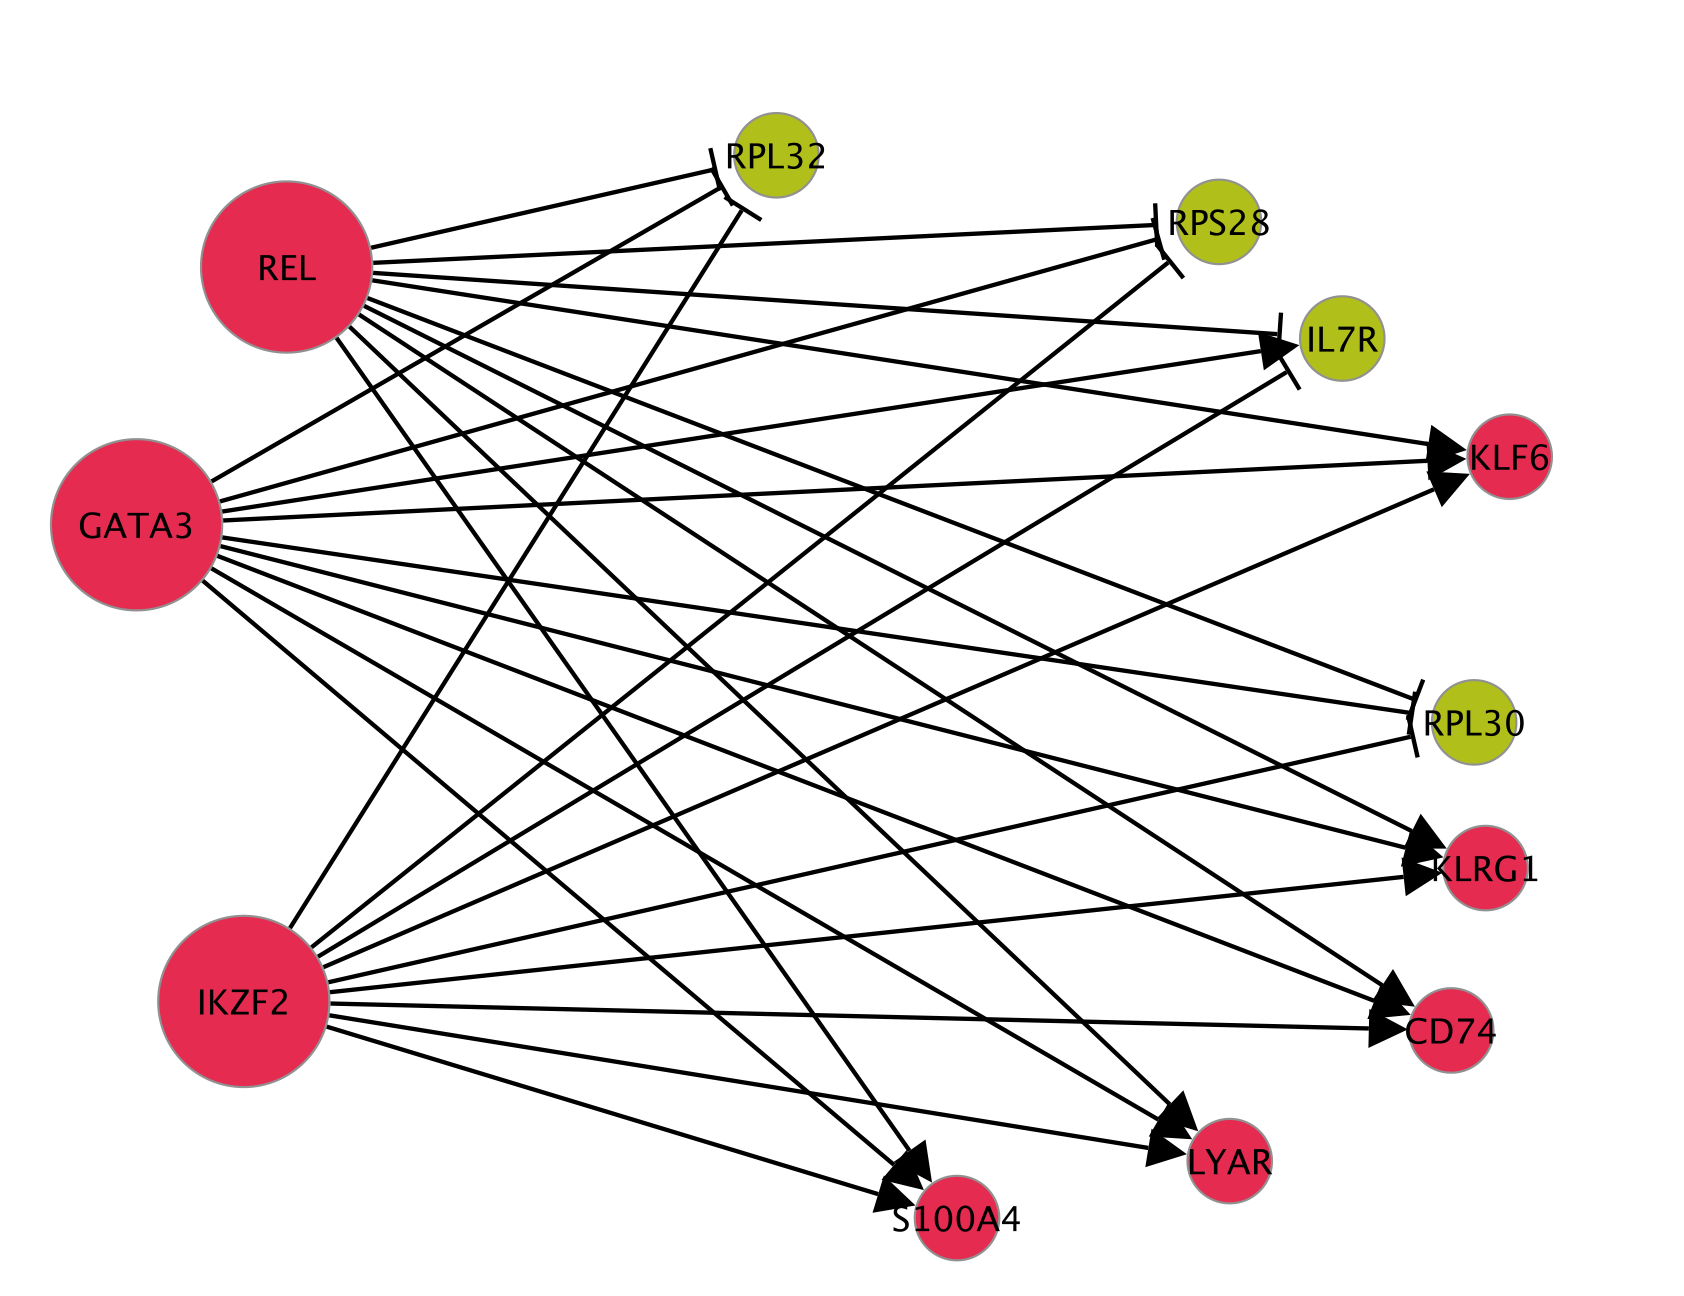

# Repo

In [ ]:
def get_tf_family():
    tf_family = pd.read_csv('../output/TableS1.csv')
    tf_family.rename(columns={'Unnamed: 1': 'TF', 'Unnamed: 2': 'family'}, inplace=True)
    tf_family = tf_family[['TF', 'family']].drop_duplicates().set_index('TF')
    return tf_family


In [ ]:

# - add additional info to the net
net['target_genes'] = net['target'].apply(lambda x: x.split('/'))
net['source_genes'] = net['source'].apply(lambda x: x.split('/'))
net['target_n'] = net['target_genes'].apply(lambda x: len(x))
net['source_n'] = net['source_genes'].apply(lambda x: len(x))

# - add tf family
tf_family = get_tf_family()

net['tf_family'] = net['source'].apply(lambda x: ', '.join(tf_family.loc[x.split('/')]['family'].unique()))

# - replace the source with tf family if the source has more than 20 names
net['source_o'] = net['source']
net['source'] = np.where(
    net['source_n'] > 20,
    net['tf_family'],
    net['source_o']
)
net.head()

import pandas as pd

# Load HGNC gene family data
hgnc_df = pd.read_csv('protein-coding_gene.csv', sep='\t')  # Replace with your actual file path


gene_to_family = hgnc_df.set_index('symbol')['gene_group'].to_dict()

# Function to map a list of genes to their families
def map_to_families(gene_list):
    families = [gene_to_family.get(gene, 'Unknown') for gene in gene_list]
    print(families)
    families = ', '.join(families)  # Join families into a single string
    return list(set(families))  # Remove duplicates

# Apply to your net DataFrame
net['target_gene_families'] = net['target_genes'].apply(map_to_families)
net

In [143]:
n_genes_t = 20
targets = net[net['target_n'] > n_genes_t]['target'].unique()
genes_list = np.concatenate([targets])


In [85]:
n_keep_terms = 5

map_gs_terms = {}
for gs in genes_list[2:3]:
    genes = gs.split('/')
    # print(genes)
    # - run ora
    import gseapy as gp
    rr = gp.enrichr(gene_list=list(genes),
                                    gene_sets=['GO_Molecular_Function_2021'], #, 'KEGG_2021_Human' ,'MSigDB_Hallmark_2020', 'GO_Molecular_Function_2021'
                                    organism='human', 
                                    outdir=None, 
                                    cutoff=1
                                    # background=list(tf_all),
                                    )
    res2d = rr.res2d
    print(res2d)
    res2d_sig = res2d[res2d['Adjusted P-value']<0.05]
    if res2d_sig.shape[0]>n_keep_terms:
        res2d_sig['n_genes'] = res2d_sig['Overlap'].apply(lambda x: x.split('/')[0]).astype(int)
        res2d_sig = res2d_sig.sort_values(by='n_genes', ascending=False).head(n_keep_terms)
    terms = res2d_sig['Term'].apply(lambda x: x.split('(')[0]).values
    terms = [term.strip() for term in terms]
    terms = '/'.join(terms)
    map_gs_terms[gs] = terms
    

                      Gene_set  \
0   GO_Molecular_Function_2021   
1   GO_Molecular_Function_2021   
2   GO_Molecular_Function_2021   
3   GO_Molecular_Function_2021   
4   GO_Molecular_Function_2021   
..                         ...   
95  GO_Molecular_Function_2021   
96  GO_Molecular_Function_2021   
97  GO_Molecular_Function_2021   
98  GO_Molecular_Function_2021   
99  GO_Molecular_Function_2021   

                                                 Term Overlap   P-value  \
0                       ribosome binding (GO:0043022)    2/48  0.007189   
1               pyrophosphatase activity (GO:0016462)    2/54  0.009029   
2   histone demethylase activity (H3-K27 specific)...     1/5  0.013181   
3          RNA strand annealing activity (GO:0033592)     1/5  0.013181   
4      ADP-ribose diphosphatase activity (GO:0047631)     1/5  0.013181   
..                                                ...     ...       ...   
95                           DNA binding (GO:0003677)   2/811  0.6